# Hotspot Detector 모델 비교

동일 이미지·동일 조건으로 **gemini-3-flash-preview**와 **gemini-3-pro-preview**의 탐지 결과를 비교합니다.

In [1]:
# Test Image Filename
TEST_IMAGE_FILENAME = "IMG_8113.jpg"

In [2]:
# 환경 설정 및 이미지 로드
import sys
import os
import time
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / ".env")

from src.utils import find_data_directory
from src.tools.experts.expert_utils import save_bytes_to_temp_file
from src.nodes.common_nodes import hotspot_detector_node
from src.state import InvestigationState

data_dir = project_root / "data"
if not data_dir.exists():
    data_dir = Path(find_data_directory())

try:
    test_image_name = (TEST_IMAGE_FILENAME or "").strip() or "Poor_Contact_001.jpg"
except NameError:
    test_image_name = "Poor_Contact_001.jpg"

test_image_path = data_dir / test_image_name
if not test_image_path.exists():
    image_files = list(data_dir.glob("*.png")) + list(data_dir.glob("*.jpg"))
    test_image_path = image_files[0] if image_files else None

if not test_image_path or not test_image_path.exists():
    raise FileNotFoundError("테스트할 이미지가 없습니다.")

with open(test_image_path, "rb") as f:
    image_data = f.read()
temp_image_path = save_bytes_to_temp_file(image_data)
print(f"✓ 테스트 이미지: {test_image_path.name}")
print(f"✓ 임시 경로: {temp_image_path[:60]}...")

✓ 테스트 이미지: IMG_8113.jpg
✓ 임시 경로: C:\Users\loidn\AppData\Local\Temp\tmp89dnjx9i.jpg...


In [3]:
# 두 모델로 Hotspot 탐지 (동일 조건)
MODELS = ["gemini-3-flash-preview", "gemini-3-pro-preview"]

def run_hotspot_detection(model_name: str):
    """지정 모델로 Hotspot 탐지 후 (결과, 소요시간) 반환"""
    os.environ["GEMINI_MODEL_NAME"] = model_name
    state = InvestigationState(
        payload=[], image_path=temp_image_path, hotspots=None,
        expert_reports=[], expert_analysis_results={}, expert_confidence_scores={},
        expert_evidence={}, final_verdict=None, errors=[],
    )
    t0 = time.perf_counter()
    result = hotspot_detector_node(state)
    elapsed = time.perf_counter() - t0
    return result, elapsed

results = {}
for model in MODELS:
    print(f"\n--- {model} 탐지 중... ---")
    try:
        result, elapsed = run_hotspot_detection(model)
        results[model] = {
            "hotspots": result.get("hotspots", []),
            "errors": result.get("errors", []),
            "elapsed_sec": elapsed,
            "count": len(result.get("hotspots", [])),
        }
        print(f"  ✓ {results[model]['count']}개 탐지, {elapsed:.1f}초 소요")
    except Exception as e:
        results[model] = {"hotspots": [], "errors": [str(e)], "elapsed_sec": 0, "count": 0}
        print(f"  ✗ 오류: {e}")


--- gemini-3-flash-preview 탐지 중... ---
2026-02-07 09:33:31 [INFO] common_nodes.hotspot_detector_node: Hotspot Detector: Using existing image path: C:\Users\loidn\AppData\Local\Temp\tmp89dnjx9i.jpg
2026-02-07 09:33:31 [INFO] common_nodes.hotspot_detector_node: Hotspot Detector: Starting analysis (Image: C:\Users\loidn\AppData\Local\Temp\tmp89dnjx9i.jpg)
2026-02-07 09:33:59 [INFO] common_nodes._call_hotspot_api: Hotspot raw response: total_count=4, len(hotspots)=4, hotspots_type=list, raw_keys=['hotspots', 'total_count', 'analysis_summary', 'scene_overview', 'detailed_observations']
2026-02-07 09:33:59 [INFO] common_nodes.hotspot_detector_node: Hotspot Detector: Found 4 hotspots
2026-02-07 09:33:59 [INFO] common_nodes.hotspot_detector_node:    - ID 1: bead_formation (Score: 92)
2026-02-07 09:33:59 [INFO] common_nodes.hotspot_detector_node:    - ID 2: carbonization (Score: 68)
2026-02-07 09:33:59 [INFO] common_nodes.hotspot_detector_node:    - ID 3: insulation_melting (Score: 75)
2026-02

In [4]:
# 성능 비교 요약
print("=" * 70)
print("Hotspot Detector 모델 비교 요약")
print("=" * 70)
print(f"{'모델':<30} {'탐지 개수':>10} {'소요 시간':>12}")
print("-" * 70)
for model in MODELS:
    r = results.get(model, {})
    cnt = r.get("count", 0)
    sec = r.get("elapsed_sec", 0)
    print(f"{model:<30} {cnt:>10}개 {sec:>10.1f}초")
print("=" * 70)

Hotspot Detector 모델 비교 요약
모델                                  탐지 개수        소요 시간
----------------------------------------------------------------------
gemini-3-flash-preview                  4개       28.4초
gemini-3-pro-preview                    4개       36.9초


In [5]:
# 모델별 Hotspot 상세 (ID, damage_type, severity_score)
for model in MODELS:
    hotspots = results.get(model, {}).get("hotspots", [])
    print(f"\n### {model}")
    print(f"{'ID':<4} {'damage_type':<22} {'severity':<8} location")
    print("-" * 60)
    for h in hotspots:
        loc = (h.get("location_description") or "")[:24]
        print(f"{h.get('id',''):<4} {str(h.get('damage_type','')):<22} {h.get('severity_score',''):<8} {loc}")
    if not hotspots:
        print("(탐지 없음)")


### gemini-3-flash-preview
ID   damage_type            severity location
------------------------------------------------------------
1    bead_formation         92       좌측 상단 절단된 전선 끝단
2    carbonization          68       좌측 상단 전선 피복부
3    insulation_melting     75       우측 커넥터 및 단자 하우징 부위
4    thermal_damage         58       중앙 우측 분산된 구리 연선 다발

### gemini-3-pro-preview
ID   damage_type            severity location
------------------------------------------------------------
1    bead_formation         92       상단 좌측 전선 끝단
2    insulation_melting     75       상단 우측 커넥터 연결부 전선
3    thermal_damage         55       하단 좌측 전선 끝단
4    carbonization          60       우측 커넥터 및 단자부


In [6]:
# damage_type 분포 비교
from collections import Counter

print("damage_type 분포:")
print(f"{'damage_type':<22} {'flash':>10} {'pro':>10}")
print("-" * 50)
all_types = set()
for model in MODELS:
    for h in results.get(model, {}).get("hotspots", []):
        all_types.add(h.get("damage_type", ""))
flash_ct = Counter(h.get("damage_type", "") for h in results.get(MODELS[0], {}).get("hotspots", []))
pro_ct = Counter(h.get("damage_type", "") for h in results.get(MODELS[1], {}).get("hotspots", []))
for dt in sorted(all_types):
    print(f"{dt:<22} {flash_ct.get(dt,0):>10} {pro_ct.get(dt,0):>10}")
print(f"{'총합':<22} {sum(flash_ct.values()):>10} {sum(pro_ct.values()):>10}")

damage_type 분포:
damage_type                 flash        pro
--------------------------------------------------
bead_formation                  1          1
carbonization                   1          1
insulation_melting              1          1
thermal_damage                  1          1
총합                              4          4


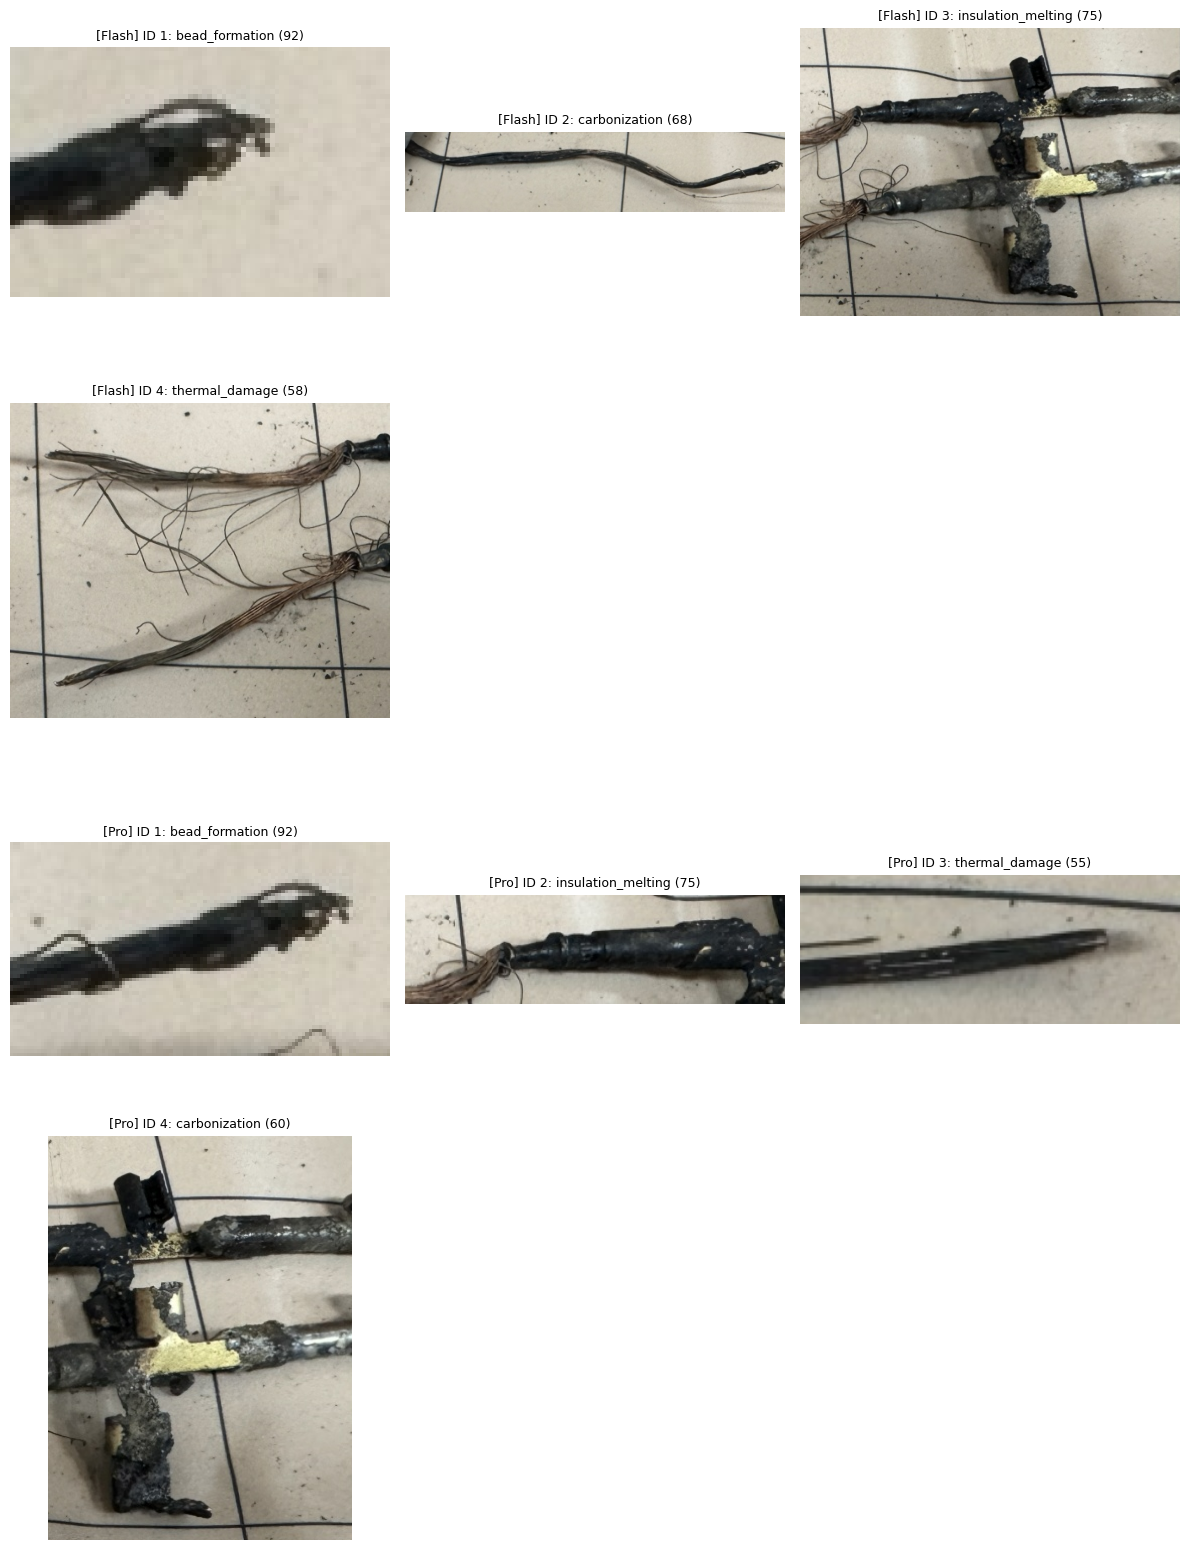

In [7]:
# 시각화: 각 모델의 Hotspot ROI 크롭 후 그리드로 비교 표시
import numpy as np
from src.utils import crop_roi_from_box
import matplotlib.pyplot as plt
from PIL import Image

max_per_model = 6
cols = 3
rows_per_model = (max_per_model + cols - 1) // cols
total_rows = rows_per_model * 2

fig, axes = plt.subplots(total_rows, cols, figsize=(12, 4 * total_rows))
axes_2d = np.atleast_2d(axes)
short_name = {"gemini-3-flash-preview": "Flash", "gemini-3-pro-preview": "Pro"}

for mi, model in enumerate(MODELS):
    hotspots = results.get(model, {}).get("hotspots", [])[:max_per_model]
    row_offset = mi * rows_per_model
    for i, h in enumerate(hotspots):
        box_2d = h.get("box_2d")
        if box_2d:
            cropped_path = crop_roi_from_box(temp_image_path, box_2d)
            img = Image.open(cropped_path)
            ax = axes_2d[row_offset + i // cols, i % cols]
            ax.imshow(img)
            ax.set_title(f"[{short_name.get(model, model)}] ID {h.get('id')}: {h.get('damage_type')} ({h.get('severity_score')})", fontsize=9)
            ax.axis("off")
    for j in range(len(hotspots), rows_per_model * cols):
        ax = axes_2d[row_offset + j // cols, j % cols]
        ax.axis("off")
    axes_2d[row_offset, 0].set_ylabel(short_name.get(model, model), fontsize=11, fontweight="bold", labelpad=40)

plt.tight_layout()
plt.show()